# 이미지로 텍스트 만들기 - 사전학습 모델 활용 (Image Captioning)

## 개요
이번 수업에서는 이미지를 보고 자동으로 그 내용을 설명하는 텍스트를 생성하는 AI 기술을 배워보겠습니다.
마치 사람이 사진을 보고 "공원에서 개가 뛰어다니고 있다"라고 설명하는 것처럼, 컴퓨터가 이미지의 내용을 이해하고 문장으로 표현하는 기술입니다.

### 실생활 활용 예시
- 시각 장애인을 위한 이미지 설명 서비스
- 소셜미디어 자동 해시태그 생성
- 의료 영상 자동 판독 보조
- 보안 CCTV 영상 자동 분석
- 온라인 쇼핑몰 상품 설명 자동 생성
- 뉴스 기사용 사진 캡션 자동 작성

### 학습 목표
1. 이미지 캡셔닝의 원리와 중요성 이해하기
2. 사전학습된 모델을 활용한 실습
3. 다양한 이미지로 캡션 생성 테스트
4. 모델의 성능과 한계점 파악하기


## 1. 이미지 캡셔닝이란?

### 기본 개념
이미지 캡셔닝은 컴퓨터가 이미지를 "보고" 그 내용을 자연어로 설명하는 기술입니다.

**예시:**
- 입력: 고양이가 소파에 앉아있는 사진
- 출력: "A cat is sitting on a sofa"

### 왜 어려운 기술일까요?
1. **시각적 이해**: 컴퓨터가 사물을 인식해야 합니다
2. **관계 파악**: 사물들 간의 관계를 이해해야 합니다 (고양이가 소파 "위에" 있다)
3. **언어 생성**: 이해한 내용을 자연스러운 문장으로 표현해야 합니다
4. **맥락 이해**: 상황에 맞는 적절한 표현을 선택해야 합니다

### 기술의 발전 과정
1. **초기**: 단순한 객체 인식 + 템플릿 문장
2. **발전**: CNN(이미지 인식) + RNN(언어 생성) 결합
3. **현재**: Transformer 기반 통합 모델 (BLIP, CLIP 등)

### 우리가 사용할 모델들
- **BLIP (Bootstrapping Language-Image Pre-training)**: 최신 이미지-텍스트 이해 모델
- **CLIP**: 이미지와 텍스트를 함께 학습한 모델
- **Git (GenerativeImage2Text)**: Microsoft에서 개발한 고성능 캡셔닝 모델


## 2. 환경 설정하기

필요한 라이브러리들을 설치하고 불러오겠습니다.


In [1]:
# 필요한 라이브러리 설치 (처음 한 번만 실행)
%pip install --upgrade pip
%pip install transformers==4.56.2 torch==2.8.0 torchvision==0.23.0 typing_extensions==4.15.0 pillow requests koreanize-matplotlib
%pip install git+https://github.com/salesforce/BLIP.git
print("라이브러리 설치가 완료되었습니다!")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/salesforce/BLIP.git to /tmp/pip-req-build-rky03atu
  Running command git clone --filter=blob:none --quiet https://github.com/salesforce/BLIP.git /tmp/pip-req-build-rky03atu
  Resolved https://github.com/salesforce/BLIP.git to commit 056a169437371659074aa2732649d5de3bffb4a8
ERROR: git+https://github.com/salesforce/BLIP.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.
라이브러리 설치가 완료되었습니다!


In [2]:
# 필요한 라이브러리들을 불러옵니다
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import GitProcessor, GitForCausalLM
from PIL import Image
import requests
import matplotlib.pyplot as plt
import koreanize_matplotlib

import numpy as np
import warnings
warnings.filterwarnings('ignore')

# GPU 사용 가능한지 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")

if device == "cpu":
    print("CPU를 사용합니다. 처리 속도가 조금 느릴 수 있습니다.")
else:
    print("GPU를 사용합니다. 빠른 처리가 가능합니다!")


사용 중인 디바이스: cuda
GPU를 사용합니다. 빠른 처리가 가능합니다!


## 3. BLIP 모델
- BLIP (Bootstrapping Language-Image Pre-training)은 멀티모달 AI 모델로, 이미지와 텍스트를 동시에 학습하여 다양한 비전-언어(Vision-Language) 작업을 수행할 수 있게 만든 모델이에요.

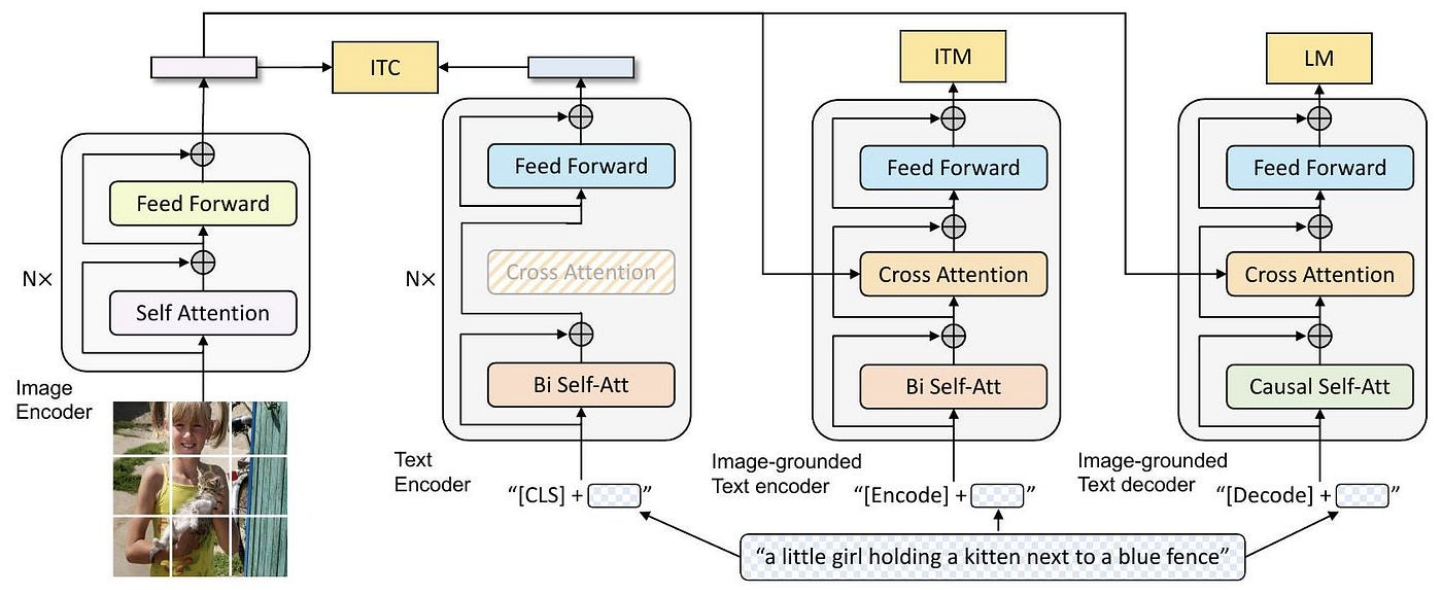

### BLIP의 핵심 아이디어
> BLIP은 단순히 "이미지를 보고 텍스트를 이해"하거나 "텍스트를 보고 이미지를 이해"하는 것이 아니라,
이미지와 언어를 **같은 표현 공간(shared representation)**에 매핑해서 양방향 학습을 가능하게 합니다.

1. 이미지 → 텍스트 (Image-to-Text)
  - 이미지를 보고 설명(캡션) 생성 (예: 이미지 캡셔닝).

2. 텍스트 → 이미지 검색 (Text-to-Image Retrieval)
  - 문장을 입력하면 가장 잘 맞는 이미지를 찾기.

3. 이미지 ↔ 텍스트 매칭 (Image-Text Matching)
  - 주어진 이미지와 문장이 서로 맞는지 판별.

4. 비전-언어 사전학습 (Pre-training)
  - 웹에서 수집한 이미지-텍스트 쌍 데이터를 이용해 거대한 사전학습을 진행.

### BLIP 모델 불러오기

BLIP(Bootstrapping Language-Image Pre-training)은 Salesforce에서 개발한 최신 이미지-텍스트 모델입니다.
이미지를 보고 자연스러운 설명을 생성하는 데 매우 뛰어난 성능을 보입니다.


In [3]:
# BLIP 모델과 프로세서 불러오기
print("BLIP 모델을 불러오는 중...")
print("처음 실행 시 모델 다운로드로 인해 시간이 걸릴 수 있습니다.")

# BLIP 모델 초기화
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# 모델을 적절한 디바이스로 이동
blip_model = blip_model.to(device)

print("BLIP 모델이 성공적으로 로드되었습니다!")
print(f"모델 크기: 약 {sum(p.numel() for p in blip_model.parameters()) / 1e6:.1f}M 파라미터")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


BLIP 모델을 불러오는 중...
처음 실행 시 모델 다운로드로 인해 시간이 걸릴 수 있습니다.


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP 모델이 성공적으로 로드되었습니다!
모델 크기: 약 224.0M 파라미터


## 4. 첫 번째 이미지 캡셔닝 테스트

이제 간단한 이미지로 첫 번째 캡셔닝을 시도해보겠습니다!


이미지를 다운로드하고 캡션을 생성하는 중...


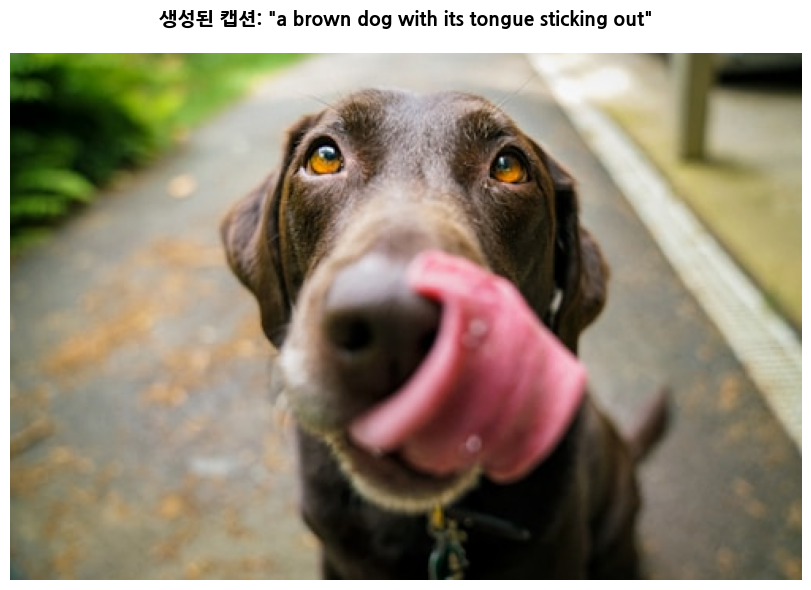

AI가 생성한 설명: a brown dog with its tongue sticking out


In [4]:
# 이미지 캡셔닝 함수 정의
def generate_caption(image, model_type="blip"):
    """
    이미지를 입력받아 설명 텍스트를 생성하는 함수

    Parameters:
    - image: PIL Image 객체 또는 이미지 경로
    - model_type: 사용할 모델 ("blip" 또는 "git")
    """

    # 이미지가 경로인 경우 PIL Image로 변환
    if isinstance(image, str):
        if image.startswith('http'):
            image = Image.open(requests.get(image, stream=True).raw)
        else:
            image = Image.open(image)

    # RGB 모드로 변환 (RGBA나 다른 모드인 경우)
    if image.mode != 'RGB':
        image = image.convert('RGB')

    if model_type == "blip":
        # BLIP 모델 사용
        inputs = blip_processor(image, return_tensors="pt").to(device)

        with torch.no_grad():
            out = blip_model.generate(**inputs, max_length=50, num_beams=5)

        caption = blip_processor.decode(out[0], skip_special_tokens=True)

    return caption

# 온라인 이미지를 사용한 첫 번째 테스트
test_image_url = "https://images.unsplash.com/photo-1518717758536-85ae29035b6d?w=500"

print("이미지를 다운로드하고 캡션을 생성하는 중...")

# 이미지 로드
test_image = Image.open(requests.get(test_image_url, stream=True).raw)

# 캡션 생성
caption = generate_caption(test_image)

# 결과 표시
plt.figure(figsize=(10, 6))
plt.imshow(test_image)
plt.axis('off')
plt.title(f'생성된 캡션: "{caption}"', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f"AI가 생성한 설명: {caption}")


## 5. 다양한 이미지로 테스트하기

이제 다양한 종류의 이미지로 캡셔닝 성능을 테스트해보겠습니다.


In [5]:
# 다양한 카테고리의 테스트 이미지들
test_images = {
    "동물": "https://images.unsplash.com/photo-1596854407944-bf87f6fdd49e?w=500",  # 고양이
    "음식": "https://images.unsplash.com/photo-1565299624946-b28f40a0ca4b?w=500",  # 피자
    "자연": "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=500",  # 산
    "사람": "https://images.unsplash.com/photo-1438761681033-6461ffad8d80?w=500",  # 여성 포트레이트
    "도시": "https://images.unsplash.com/photo-1480714378408-67cf0d13bc1f?w=500",  # 도시 야경
    "운송": "https://images.unsplash.com/photo-1549924231-f129b911e442?w=500"   # 자동차
}

print("다양한 카테고리의 이미지들로 캡셔닝 테스트를 진행합니다...")
print("각 이미지마다 처리 시간이 조금씩 걸릴 수 있습니다.")
print()

# 결과를 저장할 딕셔너리
results = {}

# 각 카테고리별로 테스트
for category, image_url in test_images.items():
    print(f"처리 중: {category}")

    try:
        # 이미지 로드
        image = Image.open(requests.get(image_url, stream=True).raw)

        # 캡션 생성
        caption = generate_caption(image)

        # 결과 저장
        results[category] = {
            'image': image,
            'caption': caption,
            'url': image_url
        }

        print(f"  완료: {caption}")

    except Exception as e:
        print(f"  오류 발생: {e}")
        results[category] = {
            'image': None,
            'caption': "처리 실패",
            'url': image_url
        }

print("\n모든 이미지 처리가 완료되었습니다!")


다양한 카테고리의 이미지들로 캡셔닝 테스트를 진행합니다...
각 이미지마다 처리 시간이 조금씩 걸릴 수 있습니다.

처리 중: 동물
  완료: a brown and white cat standing on a yellow background
처리 중: 음식
  오류 발생: cannot identify image file <_io.BytesIO object at 0x7c8b401aed90>
처리 중: 자연
  완료: a view of the mountains and clouds from the top of a mountain
처리 중: 사람
  완료: a woman with red hair standing in front of a body of water
처리 중: 도시
  오류 발생: cannot identify image file <_io.BytesIO object at 0x7c8b400ef790>
처리 중: 운송
  완료: a red and white sign with the word bond street on it

모든 이미지 처리가 완료되었습니다!


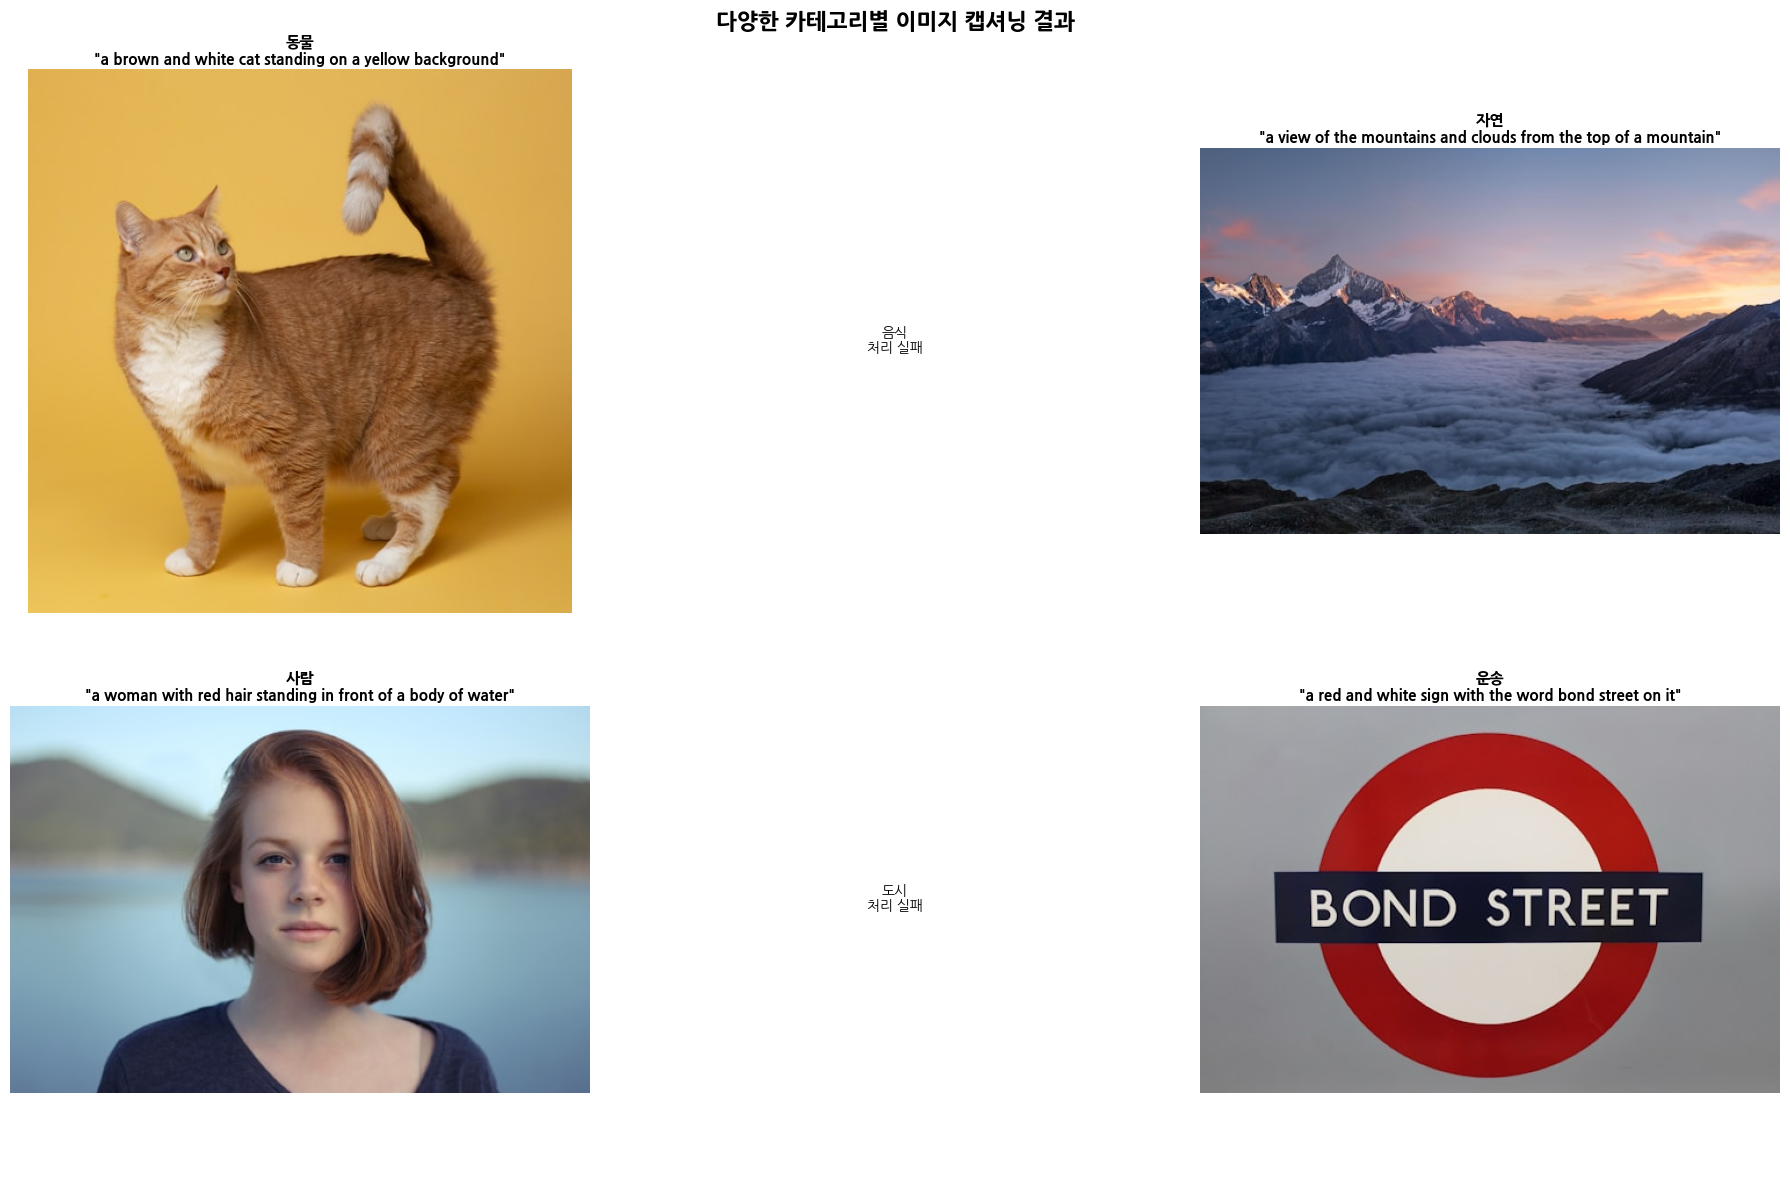


=== 카테고리별 캡셔닝 결과 요약 ===
동물    : a brown and white cat standing on a yellow background
음식    : 처리 실패
자연    : a view of the mountains and clouds from the top of a mountain
사람    : a woman with red hair standing in front of a body of water
도시    : 처리 실패
운송    : a red and white sign with the word bond street on it

분석:
- AI가 각 이미지의 주요 객체와 상황을 잘 파악하는지 확인해보세요
- 때로는 완벽하지 않은 결과가 나올 수 있습니다
- 이것이 현재 AI 기술의 현실적인 성능 수준입니다


In [6]:
# 결과를 시각적으로 표시
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('다양한 카테고리별 이미지 캡셔닝 결과', fontsize=16, fontweight='bold')

# 결과를 2x3 그리드로 배치
categories = list(results.keys())

for i, category in enumerate(categories):
    row = i // 3
    col = i % 3

    result = results[category]

    if result['image'] is not None:
        axes[row, col].imshow(result['image'])
        axes[row, col].set_title(f'{category}\n"{result["caption"]}"',
                                fontsize=11, fontweight='bold', wrap=True)
    else:
        axes[row, col].text(0.5, 0.5, f'{category}\n처리 실패',
                           ha='center', va='center', transform=axes[row, col].transAxes)

    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# 텍스트 형태로도 결과 출력
print("\n=== 카테고리별 캡셔닝 결과 요약 ===")
for category, result in results.items():
    print(f"{category:6s}: {result['caption']}")

print("\n분석:")
print("- AI가 각 이미지의 주요 객체와 상황을 잘 파악하는지 확인해보세요")
print("- 때로는 완벽하지 않은 결과가 나올 수 있습니다")
print("- 이것이 현재 AI 기술의 현실적인 성능 수준입니다")


## 6. 로컬 이미지 사용하기

여러분의 컴퓨터에 있는 이미지 파일을 사용해서 캡셔닝을 해보겠습니다.


In [7]:
# 로컬 이미지 파일을 사용한 캡셔닝
def caption_local_image(image_path):
    """
    로컬 이미지 파일의 캡션을 생성하는 함수
    """
    try:
        # 이미지 로드
        image = Image.open(image_path)

        # 캡션 생성
        caption = generate_caption(image)

        # 결과 표시
        plt.figure(figsize=(10, 8))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f'파일: {image_path.split("/")[-1]}\n생성된 캡션: "{caption}"',
                 fontsize=12, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        print(f"파일명: {image_path}")
        print(f"AI 설명: {caption}")

        return caption

    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {image_path}")
        print("올바른 이미지 파일 경로를 입력해주세요.")
        return None
    except Exception as e:
        print(f"오류가 발생했습니다: {e}")
        return None

# 예제: 로컬 이미지 파일 사용하기
# 아래 경로를 여러분의 이미지 파일 경로로 바꿔주세요
image_path = "../data/04-pizza-dad.jpeg"  # 예제 이미지 경로

print("로컬 이미지 파일로 캡셔닝을 시도합니다...")
print(f"이미지 경로: {image_path}")

# 파일이 존재하는지 확인
import os
if os.path.exists(image_path):
    local_caption = caption_local_image(image_path)
else:
    print(f"파일이 존재하지 않습니다: {image_path}")
    print()
    print("사용 방법:")
    print("1. 원하는 이미지 파일을 준비합니다")
    print("2. 위의 'image_path' 변수에 파일 경로를 입력합니다")
    print("3. 셀을 다시 실행합니다")
    print()
    print("지원하는 이미지 형식: JPG, PNG, BMP, GIF 등")


로컬 이미지 파일로 캡셔닝을 시도합니다...
이미지 경로: ../data/04-pizza-dad.jpeg
파일이 존재하지 않습니다: ../data/04-pizza-dad.jpeg

사용 방법:
1. 원하는 이미지 파일을 준비합니다
2. 위의 'image_path' 변수에 파일 경로를 입력합니다
3. 셀을 다시 실행합니다

지원하는 이미지 형식: JPG, PNG, BMP, GIF 등


## 7. Git 모델 추가하기

이제 Microsoft에서 개발한 Git(GenerativeImage2Text) 모델도 함께 사용해서 성능을 비교해보겠습니다.


In [8]:
# Git 모델 로드하기
print("Git 모델을 불러오는 중...")

try:
    # Git 모델 초기화
    git_processor = GitProcessor.from_pretrained("microsoft/git-base-coco")
    git_model = GitForCausalLM.from_pretrained("microsoft/git-base-coco")

    # 모델을 적절한 디바이스로 이동
    git_model = git_model.to(device)

    print("Git 모델이 성공적으로 로드되었습니다!")
    git_available = True

except Exception as e:
    print(f"Git 모델 로드 실패: {e}")
    print("BLIP 모델만 사용하여 계속 진행합니다.")
    git_available = False

# 개선된 캡셔닝 함수 (두 모델 지원)
def generate_caption_improved(image, model_type="blip"):
    """
    개선된 이미지 캡셔닝 함수 (BLIP과 Git 모델 지원)
    """

    # 이미지 전처리
    if isinstance(image, str):
        if image.startswith('http'):
            image = Image.open(requests.get(image, stream=True).raw)
        else:
            image = Image.open(image)

    if image.mode != 'RGB':
        image = image.convert('RGB')

    if model_type == "blip":
        # BLIP 모델 사용
        inputs = blip_processor(image, return_tensors="pt").to(device)
        with torch.no_grad():
            out = blip_model.generate(**inputs, max_length=50, num_beams=5)
        caption = blip_processor.decode(out[0], skip_special_tokens=True)

    elif model_type == "git" and git_available:
        # Git 모델 사용
        inputs = git_processor(images=image, return_tensors="pt").to(device)
        with torch.no_grad():
            out = git_model.generate(**inputs, max_length=50, num_beams=5)
        caption = git_processor.decode(out[0], skip_special_tokens=True)

    else:
        caption = "모델을 사용할 수 없습니다"

    return caption

print(f"\n사용 가능한 모델:")
print(f"- BLIP: 사용 가능")
print(f"- Git: {'사용 가능' if git_available else '사용 불가'}")


Git 모델을 불러오는 중...


preprocessor_config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/707M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/707M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Git 모델이 성공적으로 로드되었습니다!

사용 가능한 모델:
- BLIP: 사용 가능
- Git: 사용 가능


## 8. 모델 성능 비교하기

같은 이미지에 대해 다른 모델들이 어떤 설명을 생성하는지 비교해보겠습니다.


다양한 이미지로 모델 성능을 비교합니다...
이미지 로딩 중: https://images.unsplash.com/photo-1541781774459-bb2af2f05b55?w=500


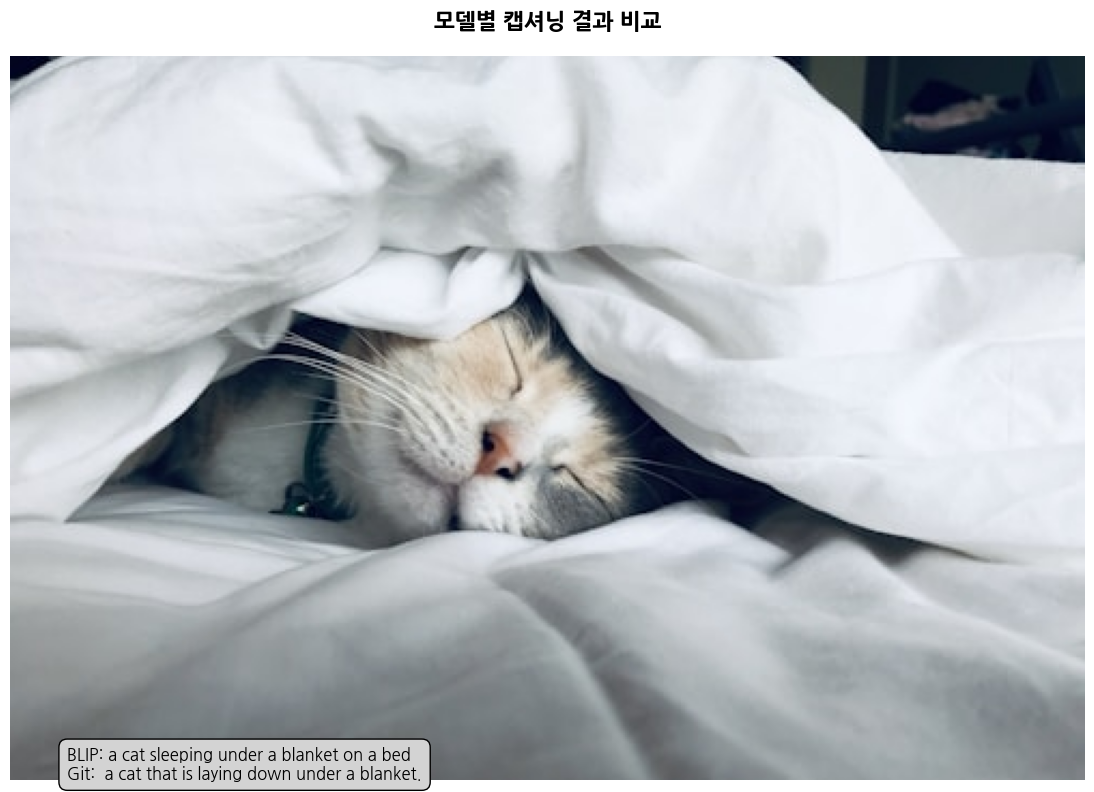


=== 모델별 결과 분석 ===
BLIP 모델: a cat sleeping under a blanket on a bed
Git 모델:  a cat that is laying down under a blanket.

관찰 포인트:
- 두 모델이 같은 객체를 인식했는지 확인
- 어떤 모델이 더 자세한 설명을 제공하는지 비교
- 문법적으로 더 자연스러운 문장을 만드는 모델 확인


In [9]:
# 모델 성능 비교 테스트
def compare_models(image_url):
    """
    여러 모델의 캡셔닝 결과를 비교하는 함수
    """
    print(f"이미지 로딩 중: {image_url}")

    try:
        # 이미지 로드
        image = Image.open(requests.get(image_url, stream=True).raw)

        # 각 모델로 캡션 생성
        blip_caption = generate_caption_improved(image, "blip")

        if git_available:
            git_caption = generate_caption_improved(image, "git")
        else:
            git_caption = "Git 모델 사용 불가"

        # 결과 표시
        plt.figure(figsize=(12, 8))
        plt.imshow(image)
        plt.axis('off')
        plt.title('모델별 캡셔닝 결과 비교', fontsize=16, fontweight='bold', pad=20)

        # 캡션들을 텍스트로 표시
        caption_text = f"BLIP: {blip_caption}\n"
        if git_available:
            caption_text += f"Git:  {git_caption}"

        plt.figtext(0.1, 0.02, caption_text, fontsize=12,
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray"))

        plt.tight_layout()
        plt.show()

        # 분석 결과 출력
        print("\n=== 모델별 결과 분석 ===")
        print(f"BLIP 모델: {blip_caption}")
        if git_available:
            print(f"Git 모델:  {git_caption}")

        print("\n관찰 포인트:")
        print("- 두 모델이 같은 객체를 인식했는지 확인")
        print("- 어떤 모델이 더 자세한 설명을 제공하는지 비교")
        print("- 문법적으로 더 자연스러운 문장을 만드는 모델 확인")

        return {
            'blip': blip_caption,
            'git': git_caption if git_available else None
        }

    except Exception as e:
        print(f"오류 발생: {e}")
        return None

# 비교 테스트용 이미지들
comparison_images = [
    "https://images.unsplash.com/photo-1541781774459-bb2af2f05b55?w=500",  # 책상 위의 강아지
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=500",  # 산 풍경
    "https://images.unsplash.com/photo-1565299624946-b28f40a0ca4b?w=500"   # 피자
]

print("다양한 이미지로 모델 성능을 비교합니다...")
print("=" * 50)

# 첫 번째 이미지로 비교 테스트
comparison_results = compare_models(comparison_images[0])


## 9. 실습: 나만의 이미지로 테스트하기

이제 여러분이 원하는 이미지로 직접 테스트해보세요!


위의 'your_image' 변수를 수정하고 다시 실행해보세요!

나만의 이미지로 테스트하기
테스트할 이미지: https://images.unsplash.com/photo-1472214103451-9374bd1c798e?w=500


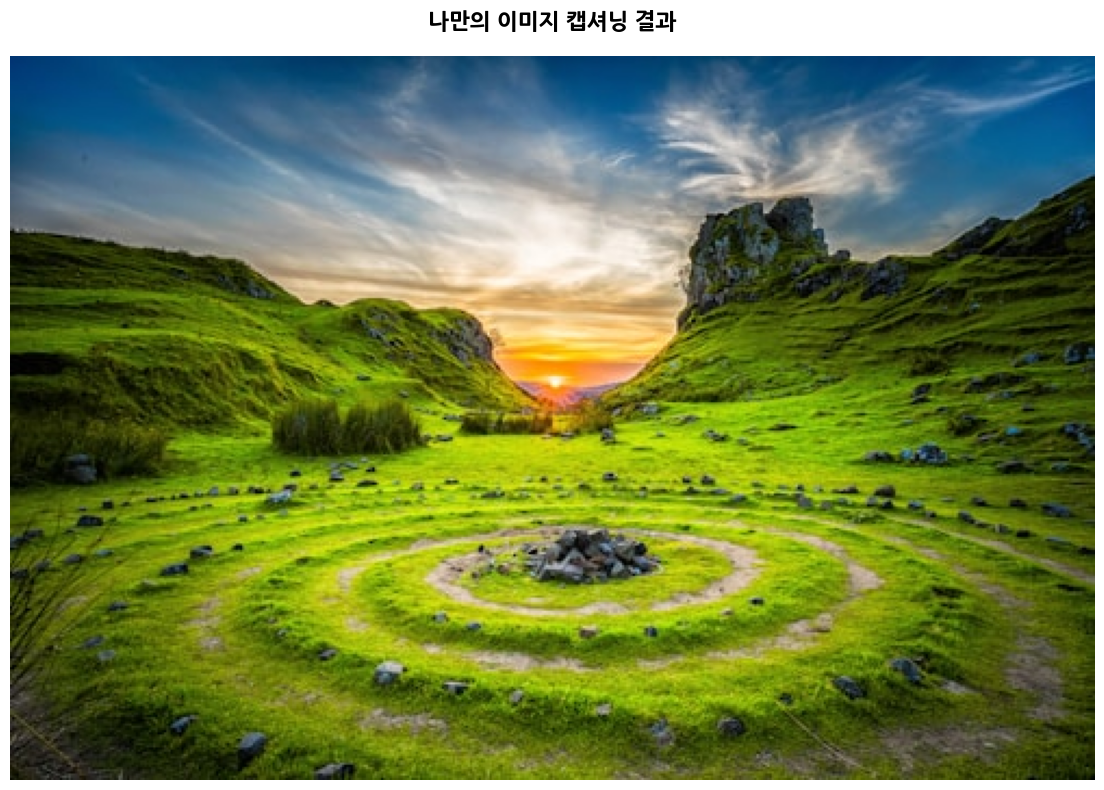


=== 캡셔닝 결과 ===
BLIP 모델: a green field with rocks in the middle and a sunset in the background
Git 모델:  the sun rises over a field of green grass.

평가해보세요:
1. AI가 이미지의 주요 객체를 올바르게 인식했나요?
2. 설명이 이미지와 얼마나 일치하나요?
3. 어떤 부분이 정확하고 어떤 부분이 부정확한가요?
4. 설명이 자연스러운 문장인가요?


In [10]:
# 사용자 정의 이미지 테스트
def test_your_image():
    """
    사용자가 선택한 이미지로 캡셔닝 테스트하는 함수
    """
    print("나만의 이미지로 테스트하기")
    print("=" * 30)

    # 여기에 여러분의 이미지 URL 또는 파일 경로를 입력하세요
    your_image = "https://images.unsplash.com/photo-1472214103451-9374bd1c798e?w=500"  # 예제 URL

    # 또는 로컬 파일 경로를 사용하려면:
    # your_image = "path/to/your/image.jpg"

    print(f"테스트할 이미지: {your_image}")

    try:
        # 이미지 로드
        if your_image.startswith('http'):
            image = Image.open(requests.get(your_image, stream=True).raw)
        else:
            image = Image.open(your_image)

        # BLIP 모델로 캡션 생성
        blip_result = generate_caption_improved(image, "blip")

        # Git 모델로 캡션 생성 (가능한 경우)
        if git_available:
            git_result = generate_caption_improved(image, "git")

        # 결과 표시
        plt.figure(figsize=(12, 8))
        plt.imshow(image)
        plt.axis('off')
        plt.title('나만의 이미지 캡셔닝 결과', fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()

        # 결과 출력
        print("\n=== 캡셔닝 결과 ===")
        print(f"BLIP 모델: {blip_result}")
        if git_available:
            print(f"Git 모델:  {git_result}")

        print("\n평가해보세요:")
        print("1. AI가 이미지의 주요 객체를 올바르게 인식했나요?")
        print("2. 설명이 이미지와 얼마나 일치하나요?")
        print("3. 어떤 부분이 정확하고 어떤 부분이 부정확한가요?")
        print("4. 설명이 자연스러운 문장인가요?")

        return {
            'image': image,
            'blip': blip_result,
            'git': git_result if git_available else None
        }

    except Exception as e:
        print(f"오류 발생: {e}")
        print("\n문제 해결 방법:")
        print("1. 이미지 URL이 올바른지 확인")
        print("2. 로컬 파일의 경우 파일 경로가 정확한지 확인")
        print("3. 이미지 파일이 손상되지 않았는지 확인")
        return None

# 테스트 실행
print("위의 'your_image' 변수를 수정하고 다시 실행해보세요!")
print()

# 실제 테스트 수행
my_result = test_your_image()


## 10. 이미지 캡셔닝의 한계와 주의사항

AI 기술의 현재 한계점을 이해하고, 실제 사용 시 주의해야 할 점들을 알아보겠습니다.


In [11]:
# 이미지 캡셔닝 한계점 분석
def analyze_limitations():
    """
    이미지 캡셔닝 기술의 한계점을 분석하고 설명하는 함수
    """
    print("=== 이미지 캡셔닝 기술의 현재 한계점 ===")
    print()

    limitations = {
        "1. 객체 인식 오류": {
            "설명": "비슷하게 생긴 객체들을 혼동할 수 있습니다",
            "예시": "고양이와 작은 강아지, 사과와 토마토 등을 잘못 인식"
        },

        "2. 맥락 이해 부족": {
            "설명": "사진의 전체적인 상황이나 배경을 완전히 이해하지 못합니다",
            "예시": "결혼식 사진을 단순히 '사람들이 모여있다'고만 설명"
        },

        "3. 세부 사항 누락": {
            "설명": "이미지의 중요한 세부 정보를 놓칠 수 있습니다",
            "예시": "감정 표현, 색상의 미묘한 차이, 브랜드나 텍스트 정보"
        },

        "4. 문화적 편향": {
            "설명": "훈련 데이터의 편향으로 인해 특정 문화권에 치우친 해석",
            "예시": "서양 문화 중심의 설명, 특정 지역의 음식이나 의상 오인식"
        },

        "5. 추상적 개념 한계": {
            "설명": "감정, 분위기, 예술적 의미 등을 표현하기 어려움",
            "예시": "슬픈 분위기의 사진을 객관적 사실로만 설명"
        }
    }

    for key, info in limitations.items():
        print(f"{key}: {info['설명']}")
        print(f"   예시: {info['예시']}")
        print()

    print("=== 실제 사용 시 주의사항 ===")
    print()

    guidelines = [
        "결과를 100% 신뢰하지 말고 항상 검증하세요",
        "중요한 의사결정에는 사람의 확인이 필요합니다",
        "여러 모델의 결과를 비교해서 사용하세요",
        "특정 도메인(의료, 법률 등)에서는 전문가 검토가 필수입니다",
        "AI는 보조 도구로 활용하고, 최종 판단은 사람이 하세요"
    ]

    for i, guideline in enumerate(guidelines, 1):
        print(f"{i}. {guideline}")

    print()
    print("=== 기술 발전 방향 ===")
    print("- 더 큰 데이터셋으로 훈련된 모델들이 계속 개발되고 있습니다")
    print("- 다중 언어 지원과 문화적 다양성이 개선되고 있습니다")
    print("- 실시간 처리 속도와 정확도가 지속적으로 향상되고 있습니다")
    print("- 특정 도메인에 특화된 모델들이 개발되고 있습니다")

# 한계점 분석 실행
analyze_limitations()


=== 이미지 캡셔닝 기술의 현재 한계점 ===

1. 객체 인식 오류: 비슷하게 생긴 객체들을 혼동할 수 있습니다
   예시: 고양이와 작은 강아지, 사과와 토마토 등을 잘못 인식

2. 맥락 이해 부족: 사진의 전체적인 상황이나 배경을 완전히 이해하지 못합니다
   예시: 결혼식 사진을 단순히 '사람들이 모여있다'고만 설명

3. 세부 사항 누락: 이미지의 중요한 세부 정보를 놓칠 수 있습니다
   예시: 감정 표현, 색상의 미묘한 차이, 브랜드나 텍스트 정보

4. 문화적 편향: 훈련 데이터의 편향으로 인해 특정 문화권에 치우친 해석
   예시: 서양 문화 중심의 설명, 특정 지역의 음식이나 의상 오인식

5. 추상적 개념 한계: 감정, 분위기, 예술적 의미 등을 표현하기 어려움
   예시: 슬픈 분위기의 사진을 객관적 사실로만 설명

=== 실제 사용 시 주의사항 ===

1. 결과를 100% 신뢰하지 말고 항상 검증하세요
2. 중요한 의사결정에는 사람의 확인이 필요합니다
3. 여러 모델의 결과를 비교해서 사용하세요
4. 특정 도메인(의료, 법률 등)에서는 전문가 검토가 필수입니다
5. AI는 보조 도구로 활용하고, 최종 판단은 사람이 하세요

=== 기술 발전 방향 ===
- 더 큰 데이터셋으로 훈련된 모델들이 계속 개발되고 있습니다
- 다중 언어 지원과 문화적 다양성이 개선되고 있습니다
- 실시간 처리 속도와 정확도가 지속적으로 향상되고 있습니다
- 특정 도메인에 특화된 모델들이 개발되고 있습니다


## 11. 실생활 응용 프로젝트

이미지 캡셔닝 기술을 실제로 어떻게 활용할 수 있는지 간단한 프로젝트를 만들어보겠습니다.


In [12]:
# 실생활 응용 프로젝트: 이미지 자동 태깅 시스템
def create_image_tagging_system():
    """
    이미지에 자동으로 태그를 생성하는 시스템 만들기
    """
    print("=== 이미지 자동 태깅 시스템 ===")
    print("소셜미디어나 사진 관리 앱에서 사용할 수 있는 자동 태깅 기능을 구현합니다.")
    print()

    # 테스트용 이미지들
    sample_images = {
        "여행": "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=500",
        "음식": "https://images.unsplash.com/photo-1565299624946-b28f40a0ca4b?w=500",
        "반려동물": "https://images.unsplash.com/photo-1596854407944-bf87f6fdd49e?w=500",
        "일상": "https://images.unsplash.com/photo-1541963463532-d68292c34d19?w=500"
    }

    results = {}

    for category, image_url in sample_images.items():
        print(f"처리 중: {category} 카테고리")

        try:
            # 이미지 로드
            image = Image.open(requests.get(image_url, stream=True).raw)

            # 캡션 생성
            caption = generate_caption_improved(image, "blip")

            # 간단한 태그 추출 (실제로는 더 정교한 NLP 처리 필요)
            tags = extract_tags_from_caption(caption)

            results[category] = {
                'image': image,
                'caption': caption,
                'tags': tags,
                'url': image_url
            }

            print(f"  완료: {len(tags)}개의 태그 생성됨")

        except Exception as e:
            print(f"  오류: {e}")

    return results

def extract_tags_from_caption(caption):
    """
    캡션에서 태그를 추출하는 간단한 함수
    실제 서비스에서는 더 정교한 NLP 기법을 사용
    """
    import re

    # 일반적인 명사들을 추출하여 태그로 사용
    common_nouns = [
        'person', 'people', 'man', 'woman', 'child', 'baby',
        'cat', 'dog', 'bird', 'animal',
        'car', 'bike', 'bicycle', 'motorcycle',
        'food', 'cake', 'pizza', 'coffee', 'drink',
        'house', 'building', 'city', 'street', 'road',
        'tree', 'flower', 'garden', 'park', 'nature',
        'beach', 'ocean', 'mountain', 'sky', 'sunset',
        'book', 'computer', 'phone', 'camera',
        'red', 'blue', 'green', 'yellow', 'black', 'white'
    ]

    caption_lower = caption.lower()
    found_tags = []

    for noun in common_nouns:
        if noun in caption_lower:
            found_tags.append(noun)

    # 중복 제거하고 최대 5개까지만
    tags = list(set(found_tags))[:5]

    return tags

# 자동 태깅 시스템 실행
tagging_results = create_image_tagging_system()


=== 이미지 자동 태깅 시스템 ===
소셜미디어나 사진 관리 앱에서 사용할 수 있는 자동 태깅 기능을 구현합니다.

처리 중: 여행 카테고리
  완료: 1개의 태그 생성됨
처리 중: 음식 카테고리
  오류: cannot identify image file <_io.BytesIO object at 0x7c8b401ac680>
처리 중: 반려동물 카테고리
  완료: 3개의 태그 생성됨
처리 중: 일상 카테고리
  오류: cannot identify image file <_io.BytesIO object at 0x7c8ae3c8f010>


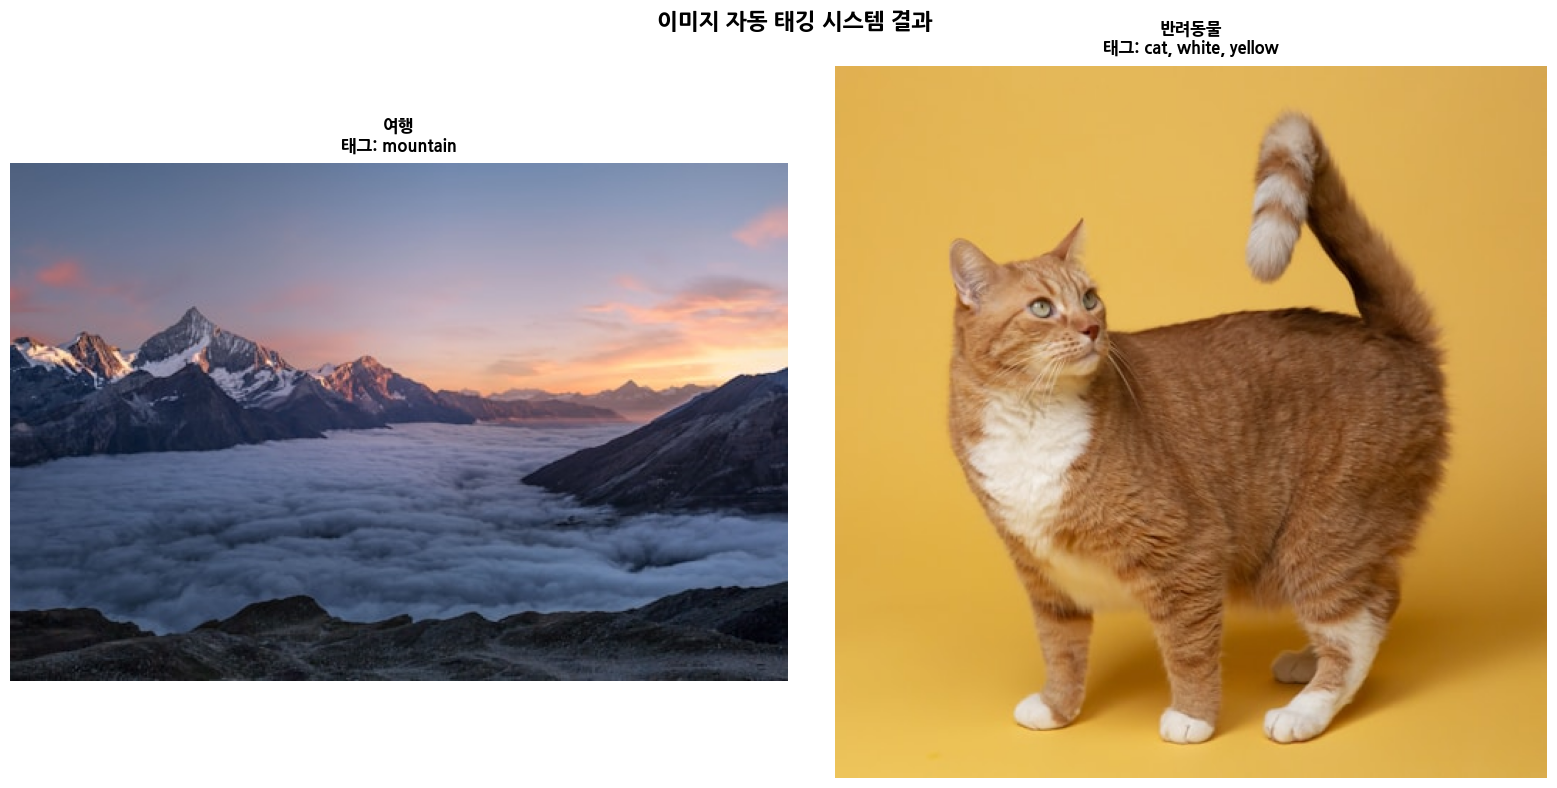


=== 자동 태깅 결과 상세 ===

여행:
  캡션: a view of the mountains and clouds from the top of a mountain
  생성된 태그: mountain

반려동물:
  캡션: a brown and white cat standing on a yellow background
  생성된 태그: cat, white, yellow

=== 실용성 평가 ===
1. 생성된 태그가 이미지 내용과 일치하는지 확인해보세요
2. 실제 사용자가 검색할 만한 키워드들이 포함되어 있는지 살펴보세요
3. 누락된 중요한 정보는 없는지 점검해보세요
4. 잘못 인식된 내용은 없는지 확인해보세요


In [13]:
# 태깅 결과 시각화
def display_tagging_results(results):
    """
    태깅 결과를 시각적으로 표시하는 함수
    """
    # 유효한 결과만 필터링
    valid_results = {k: v for k, v in results.items() if v['image'] is not None}
    categories = list(valid_results.keys())

    if not valid_results:
        print("표시할 유효한 이미지가 없습니다.")
        return

    # 그리드 크기 계산
    n_images = len(categories)
    n_cols = 2
    n_rows = (n_images + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8 * n_rows))
    fig.suptitle('이미지 자동 태깅 시스템 결과', fontsize=16, fontweight='bold')

    # axes가 1x1인 경우를 위해 리스트로 변환
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1 or n_cols == 1:
        axes = axes.reshape(n_rows, n_cols)


    for i, category in enumerate(categories):
        row = i // n_cols
        col = i % n_cols

        result = valid_results[category]

        # 이미지 표시
        axes[row, col].imshow(result['image'])
        axes[row, col].axis('off')

        # 제목과 태그 표시
        title = f"{category}\n태그: {', '.join(result['tags'])}"
        axes[row, col].set_title(title, fontsize=12, fontweight='bold', pad=10)

    # 남은 빈 axes 숨기기
    for i in range(n_images, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row, col])


    plt.tight_layout()
    plt.show()

    # 상세 결과 출력
    print("\n=== 자동 태깅 결과 상세 ===")
    for category, result in results.items():
        print(f"\n{category}:")
        print(f"  캡션: {result['caption']}")
        print(f"  생성된 태그: {', '.join(result['tags']) if result['tags'] else '태그 없음'}")

    print("\n=== 실용성 평가 ===")
    print("1. 생성된 태그가 이미지 내용과 일치하는지 확인해보세요")
    print("2. 실제 사용자가 검색할 만한 키워드들이 포함되어 있는지 살펴보세요")
    print("3. 누락된 중요한 정보는 없는지 점검해보세요")
    print("4. 잘못 인식된 내용은 없는지 확인해보세요")

# 태깅 결과 표시
if tagging_results:
    display_tagging_results(tagging_results)
else:
    print("태깅 결과가 없습니다. 위의 셀을 다시 실행해주세요.")

| 구분        | **BLIP (Bootstrapping Language-Image Pretraining)**                           | **ViT (Vision Transformer)**                                                |
| --------- | ----------------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **목적**    | 이미지와 언어를 연결하는 **멀티모달 모델**                                                     | 이미지를 이해하는 **비전 전용 모델**                                                      |
| **입력**    | 이미지 + 텍스트                                                                     | 이미지만                                                                        |
| **출력**    | - 이미지 캡션 생성 (텍스트)<br>- 이미지 ↔ 텍스트 매칭<br>- 텍스트 기반 이미지 검색                        | - 이미지 분류(label)<br>- 이미지 특징 벡터                                              |
| **구조**    | - **비전 인코더(ViT 등)** + **텍스트 인코더(Transformer)** + **크로스어텐션 모듈**                | - 이미지를 패치로 나누어 Transformer로 처리                                              |
| **학습 방식** | - 이미지-텍스트 쌍 데이터 활용<br>- Contrastive Learning, Captioning, Matching 등 다중 목표    | - 이미지 분류 데이터셋(ImageNet 등)으로 지도학습                                            |
| **강점**    | - 이미지와 언어를 동시에 이해<br>- 멀티태스킹 가능 (VQA, Captioning, Retrieval 등)                | - 글로벌 문맥 파악 능력 뛰어남<br>- 단순하고 확장성 좋음                                         |
| **약점**    | - 모델이 복잡하고 무겁다<br>- 데이터 품질(이미지-텍스트 쌍)이 성능에 큰 영향                               | - 대규모 데이터 없으면 성능 약함<br>- CNN 대비 지역 특징 학습 부족                                 |
| **대표 활용** | - 이미지 캡셔닝 (예: 사진 설명 자동 생성)<br>- 멀티모달 챗봇<br>- Stable Diffusion 보조 (프롬프트 자동 생성) | - 이미지 분류<br>- 객체 탐지/세그멘테이션 백본<br>- CLIP, BLIP, Stable Diffusion 등에서 인코더로 활용 |


# [예제 - Vit(Vision Transformer)](https://thepythoncode.com/article/image-captioning-with-pytorch-and-transformers-in-python)

## BLIP vs ViT

## [Using a Trained Model](https://huggingface.co/nlpconnect/vit-gpt2-image-captioning)

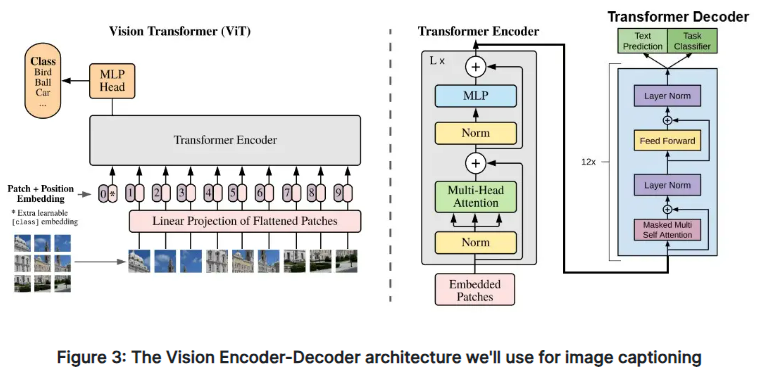

### 1. 라이브러리 설치 및 임포트

In [14]:
# 필요한 라이브러리 설치
!pip install transformers torch torchvision pillow requests koreanize-matplotlib

In [15]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from transformers import VisionEncoderDecoderModel, ViTFeatureExtractor, AutoTokenizer
from PIL import Image
import requests
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np

### 2. Vision Transformer 이미지 분류 예제

In [16]:
# 샘플 이미지 다운로드
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)


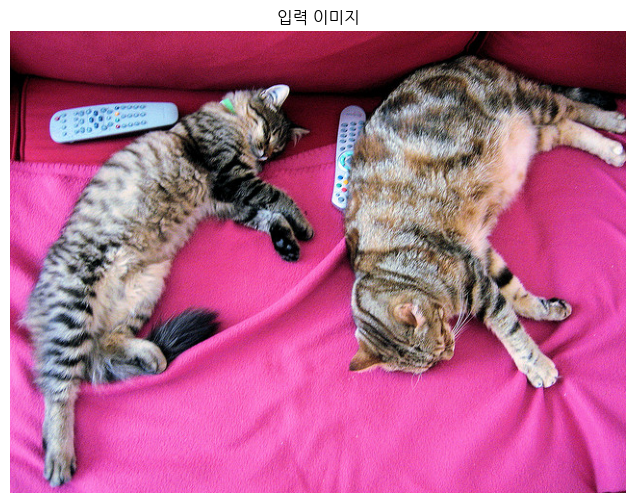

In [17]:
# 이미지 표시
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis('off')
plt.title('입력 이미지')
plt.show()

In [18]:
# ViT 모델과 프로세서 로드
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224').to(device)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [19]:
# 이미지 전처리 및 예측
inputs = processor(images=image, return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(**inputs).logits

# 예측 결과 디코딩
predicted_class_idx = logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class_idx]
confidence = torch.nn.functional.softmax(logits, dim=-1).max().item()

print(f"예측 결과: {predicted_label}")
print(f"신뢰도: {confidence:.4f}")

예측 결과: Egyptian cat
신뢰도: 0.9374


### 4. ViT의 어텐션 시각화

In [20]:
import torch.nn.functional as F
from torchvision import transforms

def visualize_attention(image_url, layer_idx=-1):
    """ViT 모델의 어텐션 맵 시각화"""

    # 이미지 로드 및 전처리
    if image_url.startswith('http'):
        image = Image.open(requests.get(image_url, stream=True).raw)
    else:
        image = Image.open(image_url)

    inputs = processor(images=image, return_tensors="pt")

    # 입력을 모델과 같은 device로 이동
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 어텐션 맵과 함께 forward pass
    with torch.no_grad():
        outputs = model(**inputs, output_attentions=True)
        attentions = outputs.attentions

    # 특정 레이어의 어텐션 맵 선택
    attention = attentions[layer_idx]  # [batch_size, num_heads, seq_len, seq_len]

    # 평균 어텐션 계산 (모든 헤드에 대해)
    attention = attention.mean(dim=1)  # [batch_size, seq_len, seq_len]
    attention = attention[0].cpu()  # 배치 차원 제거

    # CLS 토큰에 대한 어텐션만 선택 (첫 번째 토큰)
    cls_attention = attention[0, 1:]  # CLS 토큰이 다른 패치들에 주는 어텐션

    # 패치 어텐션을 이미지 형태로 변환
    num_patches = int(cls_attention.shape[0] ** 0.5)
    attention_map = cls_attention.reshape(num_patches, num_patches)

    # 원본 이미지 크기로 업샘플링
    attention_map = F.interpolate(
        attention_map.unsqueeze(0).unsqueeze(0),
        size=(224, 224),
        mode='bilinear'
    ).squeeze()

    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 원본 이미지
    axes[0].imshow(image)
    axes[0].set_title('원본 이미지')
    axes[0].axis('off')

    # 어텐션 맵
    im = axes[1].imshow(attention_map, cmap='hot', interpolation='nearest')
    axes[1].set_title('어텐션 맵')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])

    # 오버레이
    axes[2].imshow(image)
    axes[2].imshow(attention_map, cmap='hot', alpha=0.6)
    axes[2].set_title('오버레이')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()



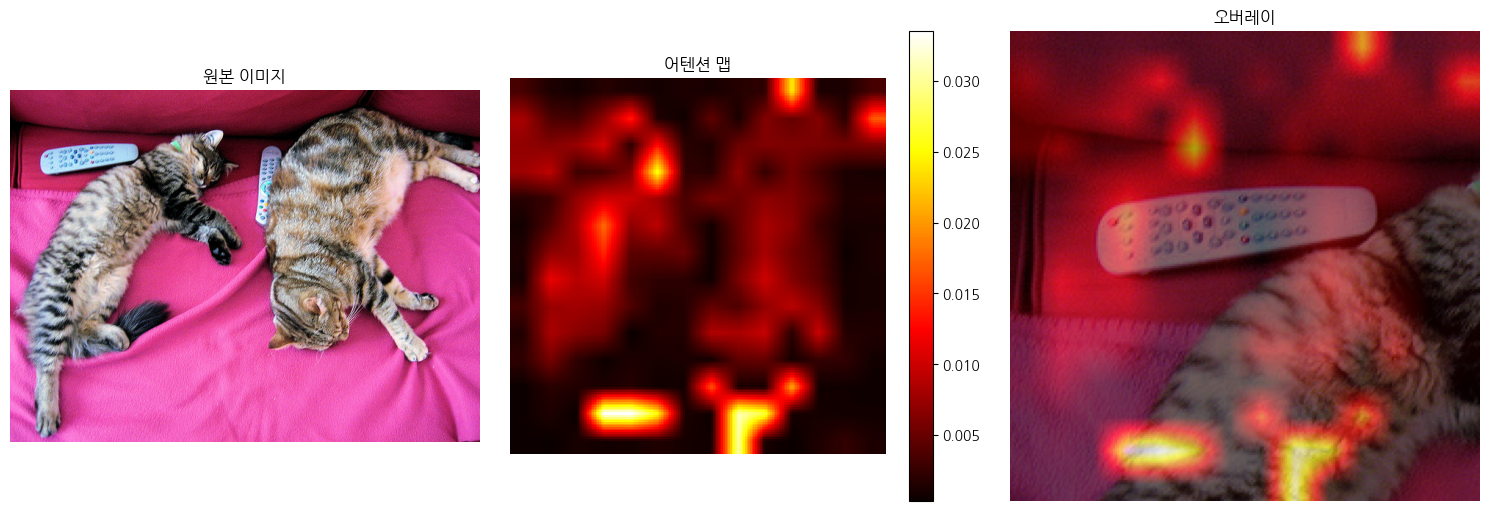

In [26]:
from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import ViTConfig

# 어텐션 출력 활성화하여 모델 로드
config = ViTConfig.from_pretrained('google/vit-base-patch16-224', output_attentions=True)
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=config
).to(device)
model.eval()

# 어텐션 시각화 실행
attention_test_image = 'http://images.cocodataset.org/val2017/000000039769.jpg'
visualize_attention(attention_test_image)

### 3. ViT + GPT2 이미지 캡셔닝 예제

In [27]:
# ViT-GPT2 이미지 캡셔닝 모델 로드
model_name = "nlpconnect/vit-gpt2-image-captioning"
model = VisionEncoderDecoderModel.from_pretrained(model_name)
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (inte

In [28]:
def predict_caption(image_path_or_url):
    """이미지에 대한 캡션 생성"""

    # 이미지 로드
    if image_path_or_url.startswith('http'):
        image = Image.open(requests.get(image_path_or_url, stream=True).raw)
    else:
        image = Image.open(image_path_or_url)

    # RGB로 변환
    if image.mode != "RGB":
        image = image.convert(mode="RGB")

    # 이미지 전처리
    pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(device)

    # 캡션 생성
    with torch.no_grad():
        output_ids = model.generate(
            pixel_values,
            max_length=16,
            num_beams=4,
            return_dict_in_generate=True
        ).sequences

    # 텍스트 디코딩
    caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    return image, caption

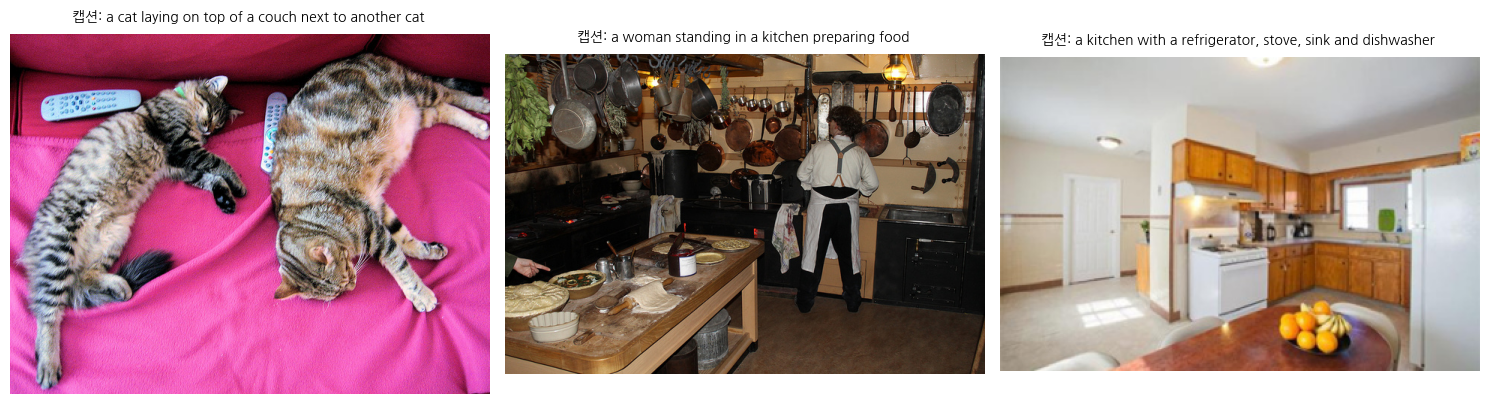

In [29]:
# 샘플 이미지들로 테스트
sample_images = [
    'http://images.cocodataset.org/val2017/000000039769.jpg',  # 고양이
    'http://images.cocodataset.org/val2017/000000397133.jpg',  # 개
    'http://images.cocodataset.org/val2017/000000037777.jpg'   # 기차
]

plt.figure(figsize=(15, 5))
for i, img_url in enumerate(sample_images):
    image, caption = predict_caption(img_url)

    plt.subplot(1, 3, i+1)
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'캡션: {caption}', fontsize=10, pad=10)

plt.tight_layout()
plt.show()